# Classificador de Textos: Humano vs IA
### DistilBERT fine-tuned — OpenAI, Meta, Google, Anthropic, Humano

## Celula 1 - Instalacao

In [ ]:
!pip uninstall datasets evaluate -y
!pip install transformers==4.40.0 tokenizers==0.19.0 scikit-learn pandas numpy torch matplotlib seaborn accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 26.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 10.8 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.6
    Uninstalling transformers-4.57.6:
      Successfully uninstalled transformers-4.57.6


## Celula 2 - Diagnostico

In [3]:
import sys
print('Python:', sys.executable)
import torch
print('PyTorch:', torch.__version__)
import transformers
print('Transformers:', transformers.__version__)
from transformers.utils import is_torch_available
print('PyTorch visivel para Transformers:', is_torch_available())
print('GPU disponivel:', torch.cuda.is_available())

Python: /usr/bin/python3
PyTorch: 2.10.0+cu128
Transformers: 5.0.0
PyTorch visivel para Transformers: True
GPU disponivel: True


## Celula 3 - Imports

In [4]:
import os
import re
import pickle
import unicodedata
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_cosine_schedule_with_warmup,
)
from torch.optim import AdamW
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print('Imports OK!')

Imports OK!


## Celula 4 - Configuracoes

In [6]:
SEED          = 42
MAX_LENGTH    = 128
BATCH_SIZE    = 64
EPOCHS        = 6
LEARNING_RATE = 2e-5
WEIGHT_DECAY  = 0.01
WARMUP_RATIO  = 0.1
DROPOUT       = 0.3
MODEL_NAME    = 'distilbert-base-uncased'
PATIENCE      = 3
NUM_LABELS    = 5

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

Dispositivo: cuda


## Celula 5 - Funcoes de limpeza

In [7]:
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^\w\s.,!?;:\'-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_text_light(text):
    text = str(text)
    text = unicodedata.normalize('NFKC', text)
    replacements = {
        '\u2018': "'", '\u2019': "'",
        '\u201c': '"', '\u201d': '"',
        '\u2013': '-', '\u2014': '-',
        '\u00a0': ' ',
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', ' ', text)
    text = re.sub(r'\r\n?', '\n', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    text = re.sub(r'[ \t]+', ' ', text)
    return text.strip()

def strip_json_edge_artifacts(text):
    text = str(text).strip()
    edge_chars = set('"\' ()[]{}')
    while text and text[0] in edge_chars:
        text = text[1:].lstrip()
    while text and text[-1] in edge_chars:
        text = text[:-1].rstrip()
    return text

print('Funcoes de limpeza OK!')

Funcoes de limpeza OK!


## Celula 6 - Carregar e preparar dados de treino

Foram testadas várias amostragens da base de dados original e foram adicionados os dados da submissão 1 com as labels reveladas.

In [20]:
DATA_PATH = 'dataset_completo.csv'
df = pd.read_csv(DATA_PATH, sep=',')
print(f'Dataset: {df.shape[0]} exemplos')
print('\nDistribuicao das classes:')
print(df['model'].value_counts())

df['content'] = df['content'].apply(clean_text)
df = df[df['content'].str.len() > 10].reset_index(drop=True)

# Sampling
N_TOTAL = 50000
N_HUMAN = N_TOTAL // 3
N_OTHER = N_TOTAL - N_HUMAN

df_human = df[df['model'] == 'Human']
df_other = df[df['model'] != 'Human']

df_human_sample = df_human.sample(n=N_HUMAN, random_state=SEED)

class_counts     = df_other['model'].value_counts()
proportions      = class_counts / class_counts.sum()
samples_per_class = (proportions * N_OTHER).astype(int)

df_other_sample = pd.concat([
    df_other[df_other['model'] == cls].sample(n=min(n, len(df_other[df_other['model'] == cls])), random_state=SEED)
    for cls, n in samples_per_class.items()
])

df_sampled = pd.concat([df_human_sample, df_other_sample]).sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f'\nApos sampling:')
print(df_sampled['model'].value_counts())
print(f'Total: {len(df_sampled)}')

# ADICIONAR DADOS DO PROFESSOR 
df_prof = pd.read_csv('subm1_labels_revealed.csv', sep=';', encoding='utf-8-sig')
df_prof = df_prof.rename(columns={'Text': 'content', 'Label': 'model'})
df_prof = df_prof[['content', 'model']]
df_prof['content'] = df_prof['content'].apply(clean_text)
df_prof = df_prof[df_prof['content'].str.len() > 10].reset_index(drop=True)
print(f'\nDados do professor: {len(df_prof)} linhas')
print(df_prof['model'].value_counts())

# Juntar ao df_sampled 
df_sampled = pd.concat([df_sampled, df_prof], ignore_index=True)
df_sampled = df_sampled.drop_duplicates(subset='content').reset_index(drop=True)
print(f'\nTotal apos adicionar dados do professor: {len(df_sampled)}')
print(df_sampled['model'].value_counts())
# --------------------------------------

# Encoding de labels 
le = LabelEncoder()
df_sampled['label'] = le.fit_transform(df_sampled['model'])
print('\nMapeamento:')
for cls, idx in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {idx} -> {cls}')

# Split
train_df, temp_df = train_test_split(df_sampled, test_size=0.30, stratify=df_sampled['label'], random_state=SEED)
val_df, test_df   = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED)
print(f'\nTreino: {len(train_df)} | Validacao: {len(val_df)} | Teste: {len(test_df)}')

Dataset: 100267 exemplos

Distribuicao das classes:
model
Human        29830
OpenAI       21141
Google       16786
Meta         16606
Anthropic    15904
Name: count, dtype: int64

Apos sampling:
model
Human        20000
OpenAI       12005
Google        9532
Meta          9430
Anthropic     9031
Name: count, dtype: int64
Total: 59998

Dados do professor: 100 linhas
model
Human        34
Meta         18
Anthropic    17
Google       17
OpenAI       14
Name: count, dtype: int64

Total apos adicionar dados do professor: 60093
model
Human        20031
OpenAI       12018
Google        9549
Meta          9448
Anthropic     9047
Name: count, dtype: int64

Mapeamento:
  0 -> Anthropic
  1 -> Google
  2 -> Human
  3 -> Meta
  4 -> OpenAI

Treino: 42065 | Validacao: 9014 | Teste: 9014


## Celula 7 - Dataset PyTorch e Tokenizer

In [21]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=MAX_LENGTH):
        encodings = tokenizer(
            list(texts),
            truncation=True,
            padding='max_length',
            max_length=max_length,
        )
        self.input_ids      = torch.tensor(encodings['input_ids'],      dtype=torch.long)
        self.attention_mask = torch.tensor(encodings['attention_mask'], dtype=torch.long)
        self.labels         = torch.tensor(list(labels),                dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels':         self.labels[idx],
        }

print('A carregar tokenizer...')
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

print('A criar datasets...')
train_dataset = TextDataset(train_df['content'], train_df['label'], tokenizer)
val_dataset   = TextDataset(val_df['content'],   val_df['label'],   tokenizer)
test_dataset  = TextDataset(test_df['content'],  test_df['label'],  tokenizer)
print('Datasets criados!')

A carregar tokenizer...
A criar datasets...
Datasets criados!


## Celula 8 - Construir modelo

In [22]:
id2label = {i: c for i, c in enumerate(le.classes_)}
label2id = {c: i for i, c in enumerate(le.classes_)}

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    seq_classif_dropout=DROPOUT,
    id2label=id2label,
    label2id=label2id,
).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parametros totais:     {total:,}')
print(f'Parametros treinaveis: {trainable:,}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parametros totais:     66,957,317
Parametros treinaveis: 66,957,317


## Celula 9 - Treino

In [23]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)

optimizer    = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

history        = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
best_val_f1    = -1
patience_count = 0
best_state     = None

print('=' * 60)
print('A iniciar treino...')
print('=' * 60)

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss       = 0.0
    train_preds_all  = []
    train_labels_all = []

    for batch in train_loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs        = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        train_loss += outputs.loss.item()
        # guarda previsoes do treino para calcular accuracy
        preds = torch.argmax(outputs.logits, dim=-1)
        train_preds_all.extend(preds.cpu().numpy())
        train_labels_all.extend(labels.cpu().numpy())

    avg_train_loss = train_loss / len(train_loader)
    train_acc      = accuracy_score(train_labels_all, train_preds_all)

    model.eval()
    val_loss, all_preds, all_labels = 0.0, [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs        = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            val_loss      += outputs.loss.item()
            preds          = torch.argmax(outputs.logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc      = accuracy_score(all_labels, all_preds)
    val_f1       = f1_score(all_labels, all_preds, average='macro')

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f'Epoch {epoch:02d}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | '
          f'Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} ')

    if val_f1 > best_val_f1 + 0.001:
        best_val_f1    = val_f1
        patience_count = 0
        best_state     = {k: v.clone() for k, v in model.state_dict().items()}
        print(f'  -> Melhor modelo guardado (F1={best_val_f1:.4f})')
    else:
        patience_count += 1
        print(f'  -> Sem melhoria ({patience_count}/{PATIENCE})')
        if patience_count >= PATIENCE:
            print(f'Early stopping na epoch {epoch}')
            break

model.load_state_dict(best_state)
print('\nTreino concluido!')

A iniciar treino...
Epoch 01/6 | Train Loss: 0.5005 | Train Acc: 0.8164 | Val Loss: 0.1047 | Val Acc: 0.9686 
  -> Melhor modelo guardado (F1=0.9661)
Epoch 02/6 | Train Loss: 0.0800 | Train Acc: 0.9762 | Val Loss: 0.0796 | Val Acc: 0.9749 
  -> Melhor modelo guardado (F1=0.9727)
Epoch 03/6 | Train Loss: 0.0371 | Train Acc: 0.9896 | Val Loss: 0.1080 | Val Acc: 0.9710 
  -> Sem melhoria (1/3)
Epoch 04/6 | Train Loss: 0.0156 | Train Acc: 0.9963 | Val Loss: 0.0894 | Val Acc: 0.9790 
  -> Melhor modelo guardado (F1=0.9776)
Epoch 05/6 | Train Loss: 0.0081 | Train Acc: 0.9981 | Val Loss: 0.0892 | Val Acc: 0.9794 
  -> Sem melhoria (1/3)
Epoch 06/6 | Train Loss: 0.0045 | Train Acc: 0.9990 | Val Loss: 0.0825 | Val Acc: 0.9817 
  -> Melhor modelo guardado (F1=0.9805)

Treino concluido!


## Celula 10 - Guardar modelo e tokenizer

In [24]:
os.makedirs('./best_model', exist_ok=True)
model.save_pretrained('./best_model')
tokenizer.save_pretrained('./best_model')

# Guardar o LabelEncoder para usar na inferencia
with open('./best_model/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print('Modelo guardado em: ./best_model')
print('Ficheiros:')
for fname in os.listdir('./best_model'):
    print(f'  {fname}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado em: ./best_model
Ficheiros:
  model.safetensors
  config.json
  tokenizer.json
  label_encoder.pkl
  tokenizer_config.json


## Celula 11 - Avaliacao no conjunto de teste

In [25]:
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
        preds          = torch.argmax(outputs.logits, dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print('Relatorio de Classificacao (conjunto de teste):')
print(classification_report(all_labels, all_preds, target_names=le.classes_, digits=4))

Relatorio de Classificacao (conjunto de teste):
              precision    recall  f1-score   support

   Anthropic     0.9763    0.9705    0.9734      1357
      Google     0.9901    0.9770    0.9835      1433
       Human     0.9966    0.9860    0.9913      3004
        Meta     0.9818    0.9894    0.9856      1417
      OpenAI     0.9616    0.9872    0.9743      1803

    accuracy                         0.9830      9014
   macro avg     0.9813    0.9820    0.9816      9014
weighted avg     0.9832    0.9830    0.9831      9014



## Celula 12 - Matriz de confusao

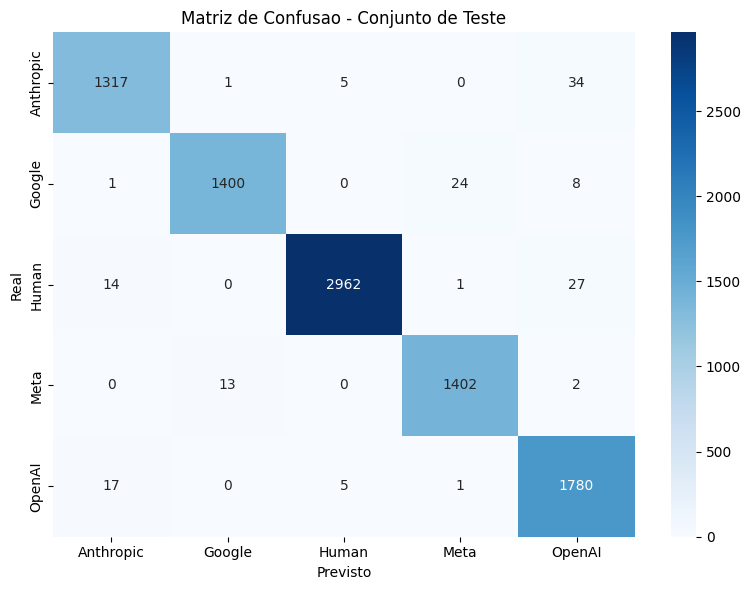

In [26]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusao - Conjunto de Teste')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## Celula 13 - Curvas de treino

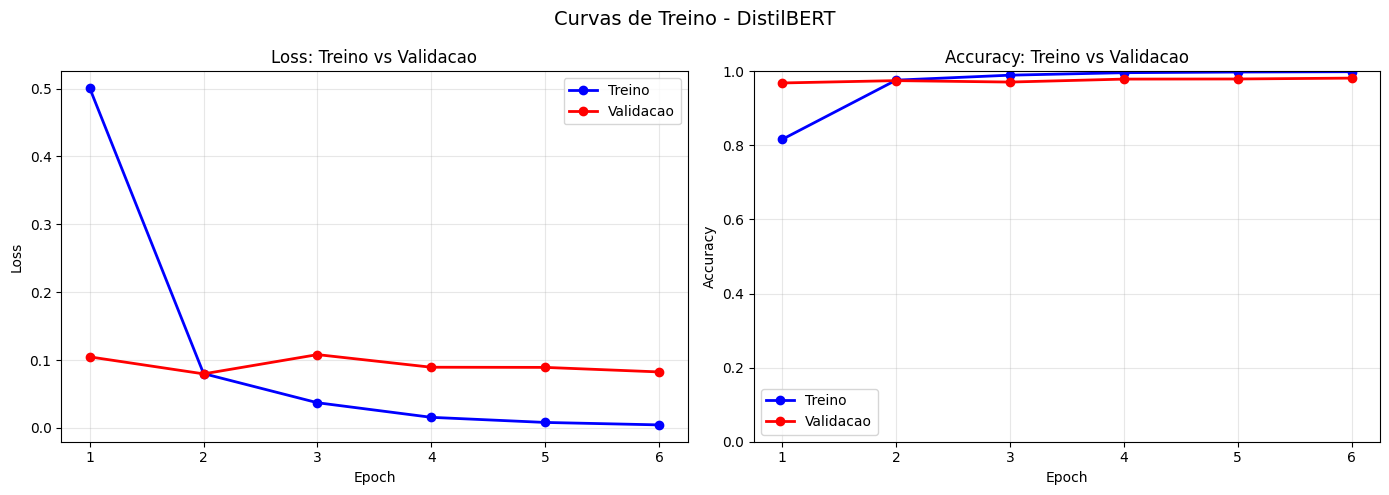

In [27]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Loss treino vs validacao
axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Treino',    linewidth=2, markersize=6)
axes[0].plot(epochs_range, history['val_loss'],   'r-o', label='Validacao', linewidth=2, markersize=6)
axes[0].set_title('Loss: Treino vs Validacao')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Accuracy treino vs validacao
axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Treino',    linewidth=2, markersize=6)
axes[1].plot(epochs_range, history['val_acc'],   'r-o', label='Validacao', linewidth=2, markersize=6)
axes[1].set_title('Accuracy: Treino vs Validacao')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de Treino - DistilBERT', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## Celula 15 - Previsoes nos dados de exemplo
### Ficheiro CSV com colunas: ID, Text, Label (Label e opcional)

In [28]:
EXEMPLOS_PATH = 'dataset-exemplos.csv'  # <- muda para o caminho do teu ficheiro
EXEMPLOS_SEP  = ';'                     # <- muda para ',' se o teu CSV usar virgula

# 1. Carrega os dados de exemplo
dados_exemplo = pd.read_csv(EXEMPLOS_PATH, sep=EXEMPLOS_SEP)
print(f'Dados de exemplo: {len(dados_exemplo)} linhas')
print(dados_exemplo.head())

# 2. Limpeza
dados_exemplo['Text'] = dados_exemplo['Text'].apply(clean_text_light)
dados_exemplo['Text'] = dados_exemplo['Text'].apply(strip_json_edge_artifacts)
dados_exemplo['Text'] = dados_exemplo['Text'].apply(clean_text)

# 3. Tokenizar
encodings = tokenizer(
    list(dados_exemplo['Text']),
    truncation=True,
    padding='max_length',
    max_length=MAX_LENGTH,
)
input_ids      = torch.tensor(encodings['input_ids'],      dtype=torch.long).to(device)
attention_mask = torch.tensor(encodings['attention_mask'], dtype=torch.long).to(device)

# 4. Previsoes em batches
model.eval()
previsoes      = []
probabilidades = []

with torch.no_grad():
    for i in range(0, len(input_ids), BATCH_SIZE):
        batch_ids   = input_ids[i:i+BATCH_SIZE]
        batch_mask  = attention_mask[i:i+BATCH_SIZE]
        outputs     = model(input_ids=batch_ids, attention_mask=batch_mask)
        probs       = torch.softmax(outputs.logits, dim=-1)
        preds       = torch.argmax(probs, dim=-1)
        for pred, prob in zip(preds.cpu().numpy(), probs.cpu().numpy()):
            previsoes.append(le.classes_[pred])
            probabilidades.append({le.classes_[j]: round(float(prob[j]), 4) for j in range(len(le.classes_))})

# 5. Adiciona previsoes
dados_exemplo['Previsao'] = previsoes

# 6. Accuracy (se existir coluna Label)
if 'Label' in dados_exemplo.columns:
    correct = (dados_exemplo['Label'] == dados_exemplo['Previsao']).sum()
    total   = len(dados_exemplo)
    acc     = correct / total
    print(f'\nAccuracy: {acc:.4f} ({correct}/{total} corretos)')
    print('\nRelatorio de Classificacao:')
    print(classification_report(dados_exemplo['Label'], dados_exemplo['Previsao'], digits=4))

# 7. Mostrar resultados
cols = ['ID', 'Label', 'Previsao'] if 'Label' in dados_exemplo.columns else ['ID', 'Previsao']
print('\nResultados:')
print(dados_exemplo[cols].to_string(index=False))

Dados de exemplo: 125 linhas
     ID                                               Text   Label
0  D1-1  It is an approximation useful in chemistry, bu...   Human
1  D1-2  PET scanning, or Positron Emission Tomography,...    Meta
2  D1-3  Positron Emission Tomography (PET) scanning is...  Google
3  D1-4  Thermonuclear fusion is the process of combini...    Meta
4  D1-5  These nutrients are needed to keep bones, teet...   Human

Accuracy: 0.5120 (64/125 corretos)

Relatorio de Classificacao:
              precision    recall  f1-score   support

   Anthropic     0.3922    0.8696    0.5405        23
      Google     1.0000    0.0625    0.1176        16
       Human     0.8611    0.5962    0.7045        52
        Meta     0.0000    0.0000    0.0000        17
      OpenAI     0.3243    0.7059    0.4444        17

    accuracy                         0.5120       125
   macro avg     0.5155    0.4468    0.3614       125
weighted avg     0.6025    0.5120    0.4681       125


Resultados:
  

Dados de exemplo: 125 linhas
     ID                                               Text   Label
0  D1-1  It is an approximation useful in chemistry, bu...   Human
1  D1-2  PET scanning, or Positron Emission Tomography,...    Meta
2  D1-3  Positron Emission Tomography (PET) scanning is...  Google
3  D1-4  Thermonuclear fusion is the process of combini...    Meta
4  D1-5  These nutrients are needed to keep bones, teet...   Human

Accuracy: 0.5680 (71/125 corretos)

Relatorio de Classificacao:
              precision    recall  f1-score   support

   Anthropic     0.3818    0.9130    0.5385        23
      Google     0.7500    0.1875    0.3000        16
       Human     0.8919    0.6346    0.7416        52
        Meta     0.8571    0.3529    0.5000        17
      OpenAI     0.3636    0.4706    0.4103        17

    accuracy                         0.5680       125
   macro avg     0.6489    0.5117    0.4981       125
weighted avg     0.7033    0.5680    0.5698       125

Accuracy por cl

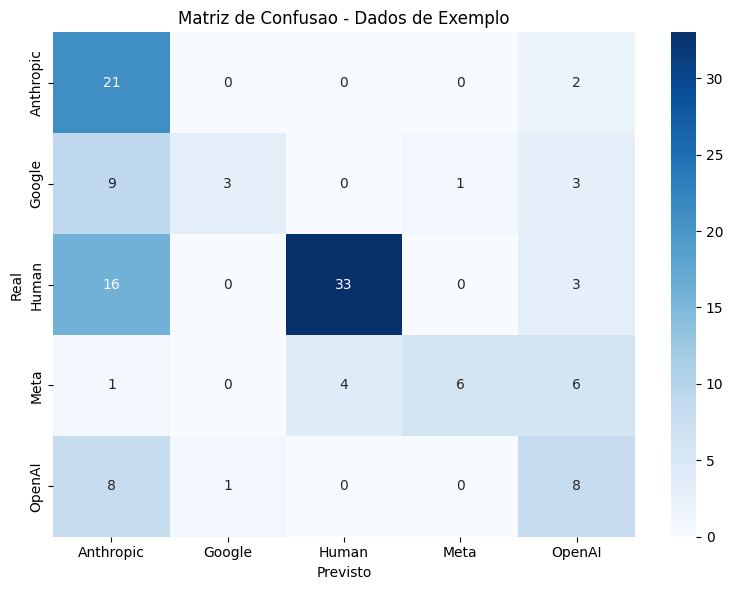


Resultados:
    ID     Label  Previsao
  D1-1     Human     Human
  D1-2      Meta      Meta
  D1-3    Google      Meta
  D1-4      Meta      Meta
  D1-5     Human Anthropic
  D1-6    Google    OpenAI
  D1-7    OpenAI Anthropic
  D1-8      Meta    OpenAI
  D1-9    Google Anthropic
 D1-10     Human Anthropic
 D1-11      Meta     Human
 D1-12     Human    OpenAI
 D1-13    Google Anthropic
 D1-14    Google Anthropic
 D1-15 Anthropic Anthropic
 D1-16    OpenAI    OpenAI
 D1-17     Human     Human
 D1-18     Human Anthropic
 D1-19    Google    Google
 D1-20 Anthropic Anthropic
 D1-21    OpenAI Anthropic
 D1-22    Google    Google
 D1-23    OpenAI Anthropic
 D1-24 Anthropic Anthropic
 D1-25 Anthropic Anthropic
 D1-26     Human     Human
 D1-27     Human Anthropic
 D1-28    OpenAI    Google
 D1-29     Human     Human
 D1-30 Anthropic Anthropic
 D1-31     Human     Human
 D1-32     Human     Human
 D1-33      Meta    OpenAI
 D1-34     Human     Human
 D1-35 Anthropic Anthropic
 D1-36    Googl

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

EXEMPLOS_PATH = 'dataset-exemplos.csv'
EXEMPLOS_SEP  = ';'

# 1. Carregar os dados de exemplo
dados_exemplo = pd.read_csv(EXEMPLOS_PATH, sep=EXEMPLOS_SEP)
print(f'Dados de exemplo: {len(dados_exemplo)} linhas')
print(dados_exemplo.head())

# 2. Limpeza
dados_exemplo['Text'] = dados_exemplo['Text'].apply(clean_text_light)
dados_exemplo['Text'] = dados_exemplo['Text'].apply(strip_json_edge_artifacts)
dados_exemplo['Text'] = dados_exemplo['Text'].apply(clean_text)

# 3. Tokenizar
encodings = tokenizer(
    list(dados_exemplo['Text']),
    truncation=True,
    padding='max_length',
    max_length=MAX_LENGTH,
)
input_ids      = torch.tensor(encodings['input_ids'],      dtype=torch.long).to(device)
attention_mask = torch.tensor(encodings['attention_mask'], dtype=torch.long).to(device)

# 4. Previsoes em batches
model.eval()
previsoes      = []
probabilidades = []

with torch.no_grad():
    for i in range(0, len(input_ids), BATCH_SIZE):
        batch_ids  = input_ids[i:i+BATCH_SIZE]
        batch_mask = attention_mask[i:i+BATCH_SIZE]
        outputs    = model(input_ids=batch_ids, attention_mask=batch_mask)
        probs      = torch.softmax(outputs.logits, dim=-1)
        preds      = torch.argmax(probs, dim=-1)
        for pred, prob in zip(preds.cpu().numpy(), probs.cpu().numpy()):
            previsoes.append(le.classes_[pred])
            probabilidades.append({le.classes_[j]: round(float(prob[j]), 4) for j in range(len(le.classes_))})

# 5. Adicionar previsoes
dados_exemplo['Previsao'] = previsoes

# 6. Accuracy e metricas detalhadas
if 'Label' in dados_exemplo.columns:
    correct = (dados_exemplo['Label'] == dados_exemplo['Previsao']).sum()
    total   = len(dados_exemplo)
    acc     = correct / total
    print(f'\nAccuracy: {acc:.4f} ({correct}/{total} corretos)')

    # Classification report
    print('\nRelatorio de Classificacao:')
    print(classification_report(dados_exemplo['Label'], dados_exemplo['Previsao'], digits=4))

    # Accuracy por classe
    print('Accuracy por classe:')
    for classe in sorted(dados_exemplo['Label'].unique()):
        mask = dados_exemplo['Label'] == classe
        c    = (dados_exemplo.loc[mask, 'Label'] == dados_exemplo.loc[mask, 'Previsao']).sum()
        t    = mask.sum()
        print(f'  {classe:<12}: {c/t:.4f} ({c}/{t})')

    # Matriz de confusao
    classes_presentes = [l for l in le.classes_ if l in dados_exemplo['Label'].unique()]
    cm = confusion_matrix(dados_exemplo['Label'], dados_exemplo['Previsao'], labels=classes_presentes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes_presentes, yticklabels=classes_presentes)
    plt.title('Matriz de Confusao - Dados de Exemplo')
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.tight_layout()
    plt.show()

# 7. Mostrar resultados
cols = ['ID', 'Label', 'Previsao'] if 'Label' in dados_exemplo.columns else ['ID', 'Previsao']
print('\nResultados:')
print(dados_exemplo[cols].to_string(index=False))

## Celula 16 - Exportar resultados para CSV

In [ ]:
# Adicionar probabilidades por classe
probs_df = pd.DataFrame(probabilidades)
probs_df.columns = [f'prob_{c}' for c in probs_df.columns]
resultado_final = pd.concat([dados_exemplo.reset_index(drop=True), probs_df], axis=1)

resultado_final.to_csv('previsoes_exemplos.csv', index=False, sep=';')
print('Resultados guardados em: previsoes_exemplos.csv')
print(resultado_final.head())

In [19]:
# ============================================================
# PREVISOES NOS DADOS DE SUBMISSAO
# ============================================================

SUBMISSAO_PATH = 'subm2.csv'   
SUBMISSAO_SEP  = ';'          

# 1. Carregar os dados de submissao
df_subm = pd.read_csv(SUBMISSAO_PATH, sep=SUBMISSAO_SEP)
print(f'Dados de submissao carregados: {len(df_subm)} linhas')
print(f'Colunas: {df_subm.columns.tolist()}')
print(df_subm.head())

# 2. Limpeza do texto
df_subm['Text'] = df_subm['Text'].apply(clean_text_light)
df_subm['Text'] = df_subm['Text'].apply(strip_json_edge_artifacts)
textos_limpos   = df_subm['Text'].apply(clean_text).tolist()

# 3. Tokenizar
encodings      = tokenizer(
    textos_limpos,
    truncation=True,
    padding='max_length',
    max_length=MAX_LENGTH,
)
input_ids      = torch.tensor(encodings['input_ids'],      dtype=torch.long).to(device)
attention_mask = torch.tensor(encodings['attention_mask'], dtype=torch.long).to(device)

# 4. Previsoes em batches
model.eval()
previsoes = []

with torch.no_grad():
    for i in range(0, len(input_ids), BATCH_SIZE):
        batch_ids   = input_ids[i:i+BATCH_SIZE]
        batch_mask  = attention_mask[i:i+BATCH_SIZE]
        outputs     = model(input_ids=batch_ids, attention_mask=batch_mask)
        preds       = torch.argmax(outputs.logits, dim=-1)
        for pred in preds.cpu().numpy():
            previsoes.append(le.classes_[pred])

# 5. Adicionar coluna Label
df_subm['Label'] = previsoes

# 6. Mostrar distribuicao das previsoes
print('\nDistribuicao das previsoes:')
print(df_subm['Label'].value_counts())

# 7. Guardar o ficheiro final
df_subm.to_csv('subm2_com_labels_MODELO3.csv', index=False, sep=';')
print(f'\nFicheiro guardado: subm2_com_labels.csv')
print(df_subm[['ID', 'Label']].to_string(index=False))

Dados de submissao carregados: 150 linhas
Colunas: ['ID', 'Text']
       ID                                               Text
0  D2-101  Microbial mats of coexisting bacteria and arch...
1  D2-102  The origin of life on Earth remains a complex ...
2  D2-103  Estimates of the time at which life arose on E...
3  D2-104  Life on Earth emerged roughly 3.8-4 billion ye...
4  D2-105  Black holes predominantly form from the catast...

Distribuicao das previsoes:
Label
Anthropic    63
Human        39
OpenAI       24
Meta         22
Google        2
Name: count, dtype: int64

Ficheiro guardado: subm2_com_labels.csv
    ID     Label
D2-101     Human
D2-102    OpenAI
D2-103     Human
D2-104 Anthropic
D2-105 Anthropic
D2-106 Anthropic
D2-107      Meta
D2-108 Anthropic
D2-109 Anthropic
D2-110     Human
D2-111 Anthropic
D2-112 Anthropic
D2-113    OpenAI
D2-114    OpenAI
D2-115      Meta
D2-116 Anthropic
D2-117     Human
D2-118 Anthropic
D2-119    OpenAI
D2-120      Meta
D2-121     Human
D2-122     H